<a href="https://colab.research.google.com/github/MohammadRezaNamvarNejad/ABSA-LLM/blob/main/Gemma_3_4BRAG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
# ==========================================
# 0. Install deps
# ==========================================
# skip torch upgrade to avoid breaking Colab CUDA
!pip install -q transformers accelerate bitsandbytes sentence-transformers faiss-cpu
import torch
import xml.etree.ElementTree as ET
import pandas as pd
import numpy as np
import gc
import re
from sentence_transformers import SentenceTransformer
import faiss
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

# free GPU memory before starting
torch.cuda.empty_cache()
gc.collect()

10192

In [10]:
# ==========================================
# 1. Data pipeline
# ==========================================
xml_filename = "ABSA16_Restaurants_Train_SB1_v2.xml"

def parse_xml_safe(file_path):
    dataset = []
    try:
        tree = ET.parse(file_path)
        for review in tree.getroot().findall('Review'):
            sentences = review.find('sentences')
            if not sentences: continue
            for sentence in sentences.findall('sentence'):
                text = sentence.find('text').text
                opinions = sentence.find('Opinions')
                if not opinions: continue
                for opinion in opinions.findall('Opinion'):
                    if opinion.get('polarity') == "conflict": continue
                    dataset.append({
                        "text": text,
                        "aspect": opinion.get('category'),
                        "true_label": opinion.get('polarity')
                    })
        return dataset
    except: return []

# try loading the XML file
full_data = parse_xml_safe(xml_filename)

if full_data:
    split = int(len(full_data) * 0.9)
    training_set = full_data[:split]
    testing_set = full_data[split:][:50]
    print(f"Loaded data — train: {len(training_set)} | test: {len(testing_set)}")
else:
    print("XML not found; using dummy data.")
    training_set = [{"text": "Great food.", "aspect": "FOOD#QUALITY", "true_label": "positive"}]
    testing_set = [{"text": "Bad service.", "aspect": "SERVICE#GENERAL", "true_label": "negative"}]

# RAG setup (shared benchmark protocol)
encoder = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
index = faiss.IndexFlatL2(384)
if training_set:
    embeddings = encoder.encode([d['text'] for d in training_set])
    index.add(np.array(embeddings).astype('float32'))

def retrieve_rag(query, k=3):
    if not training_set: return []
    q_emb = encoder.encode([query])
    _, idxs = index.search(np.array(q_emb).astype('float32'), k)
    return [training_set[i] for i in idxs[0]]

/tmp/ipykernel_443/449879154.py:12: DeprecationWarning: Testing an element's truth value will always return True in future versions.  Use specific 'len(elem)' or 'elem is not None' test instead.
  if not sentences: continue
/tmp/ipykernel_443/449879154.py:16: DeprecationWarning: Testing an element's truth value will always return True in future versions.  Use specific 'len(elem)' or 'elem is not None' test instead.
  if not opinions: continue


✅ داده‌ها لود شد. آموزش: 2256 | تست: 50


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [13]:
# import os

# # optional: set HF token manually for Gemma
# os.environ["HF_TOKEN"] = "YOUR_TOKEN"
# print("HF token set manually")

import os
from google.colab import userdata

# read HF token from Colab secrets
try:
    os.environ["HF_TOKEN"] = userdata.get('HF_TOKEN')
    print("HF token found in Colab secrets.")
except:
    print("HF_TOKEN not set in Colab secrets.")

✅ توکن Hugging Face به صورت دستی با موفقیت تنظیم شد.


In [12]:
# ==========================================
# 2. Run gemma-3-4b-it
# ==========================================
model_name = "google/gemma-3-4b-it"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

def generate_unified_prompt(method, sample):
    # base instruction (zero-shot template)
    base_instruction = (
        "Task: Aspect-Based Sentiment Analysis (ABSA) on Restaurant Reviews.\n"
        "Classify the sentiment polarity of the target aspect into exactly one of these labels: positive, negative, or neutral.\n"
        f'Sentence: "{sample["text"]}"\n'
        f'Target Aspect: "{sample["aspect"]}"\n'
        "Output ONLY the final sentiment label in lowercase."
    )

    if method == "Zero-Shot":
        user_msg = base_instruction

    elif method == "One-Shot":
        # fixed one-shot example (not from the index)
        user_msg = (
            "Task: Aspect-Based Sentiment Analysis (ABSA) on Restaurant Reviews.\n"
            "Classify the sentiment polarity of the target aspect into exactly one of these labels: positive, negative, or neutral.\n"
            'Sentence: "{text}"\n'
            'Target Aspect: "{aspect}"\n'
            "Output ONLY the final sentiment label in lowercase.\n\n"
            "Example:\n"
            'Sentence: "The food was absolutely delicious, but the service was terrible."\n'
            'Target Aspect: "food"\n'
            "Sentiment: positive\n\n"
            "Now classify the following:\n"
            f'Sentence: "{sample["text"]}"\n'
            f'Target Aspect: "{sample["aspect"]}"\n'
            "Sentiment:"
        )

    elif method == "RAG":
        # retrieve exactly 3 examples
        rets = retrieve_rag(sample['text'], k=3)

        # pad with placeholders if fewer than 3 hits
        while len(rets) < 3:
            rets.append({"text": "N/A", "aspect": "N/A", "true_label": "neutral"})

        user_msg = (
            "Task: Aspect-Based Sentiment Analysis (ABSA) on Restaurant Reviews.\n"
            "Classify the sentiment polarity of the target aspect into exactly one of these labels: positive, negative, or neutral.\n"
            'Sentence: "{text}"\n'
            'Target Aspect: "{aspect}"\n'
            "Output ONLY the final sentiment label in lowercase.\n\n"
            "Here are some reference examples:\n"
            f'Sentence: "{rets[0]["text"]}" | Target Aspect: "{rets[0]["aspect"]}" -> Sentiment: {rets[0]["true_label"]}\n'
            f'Sentence: "{rets[1]["text"]}" | Target Aspect: "{rets[1]["aspect"]}" -> Sentiment: {rets[1]["true_label"]}\n'
            f'Sentence: "{rets[2]["text"]}" | Target Aspect: "{rets[2]["aspect"]}" -> Sentiment: {rets[2]["true_label"]}\n\n'
            "Now classify the following:\n"
            f'Sentence: "{sample["text"]}"\n'
            f'Target Aspect: "{sample["aspect"]}"\n'
            "Sentiment:"
        )

    # single user message for cross-model consistency
    return [{"role": "user", "content": user_msg}]

def clean_output_label(text):
    text = text.lower().strip()
    # regex extract allowed label; drop junk tokens
    match = re.search(r'\b(positive|negative|neutral)\b', text)
    if match:
        return match.group(1)
    return "neutral"  # fallback if output does not match

print(f"\nRunning {model_name}...")
gemma_results = []

try:
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForCausalLM.from_pretrained(model_name, quantization_config=bnb_config, device_map="auto")
    print("Model loaded.")

    for method in ["Zero-Shot", "One-Shot", "RAG"]:
        print(f"  Running {method}...")
        correct = 0
        total = 0

        for sample in testing_set:
            try:
                msgs = generate_unified_prompt(method, sample)

                # move padded tensors to GPU explicitly
                inputs = tokenizer.apply_chat_template(
                    msgs,
                    return_tensors="pt",
                    return_dict=True,  # dict output for safe access
                    add_generation_prompt=True
                ).to(model.device)

                with torch.no_grad():
                    # pass input_ids directly to generate()
                    outputs = model.generate(
                        inputs["input_ids"],
                        attention_mask=inputs.get("attention_mask", None),
                        max_new_tokens=5,
                        do_sample=False
                    )

                # slice off prompt tokens from the output
                generated_ids = outputs[0][inputs["input_ids"].shape[-1]:]
                decoded = tokenizer.decode(generated_ids, skip_special_tokens=True)

                pred = clean_output_label(decoded)

                if pred == sample['true_label'].lower().strip():
                    correct += 1
                total += 1

            except Exception as inner_e:
                import traceback
                print(f"    ❌ Error details for sample: {str(inner_e)}")
                traceback.print_exc()
                break  # stop on first error for debugging

        acc = (correct / total) * 100 if total > 0 else 0
        print(f"    -> Accuracy: {acc:.2f}%")
        gemma_results.append({"Model": "gemma-3-4b-it", "Method": method, "Accuracy": acc})

except Exception as e:
    print(f"\nCRITICAL ERROR: {e}")

print("\nResults (unified benchmark protocol):")
print(pd.DataFrame(gemma_results))


🚀 شروع پردازش google/gemma-3-4b-it...


Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


✅ مدل با موفقیت بارگذاری شد.
  Running Zero-Shot...


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


    -> Accuracy: 88.00%
  Running One-Shot...
    -> Accuracy: 82.00%
  Running RAG...
    -> Accuracy: 84.00%

نتایج مدل با استاندارد یکپارچه پژوهشی:
           Model     Method  Accuracy
0  gemma-3-4b-it  Zero-Shot      88.0
1  gemma-3-4b-it   One-Shot      82.0
2  gemma-3-4b-it        RAG      84.0


جدول نهایی نتایج:
           Model     Method  Accuracy
0  gemma-3-4b-it  Zero-Shot      88.0
1  gemma-3-4b-it   One-Shot      82.0
2  gemma-3-4b-it        RAG      84.0


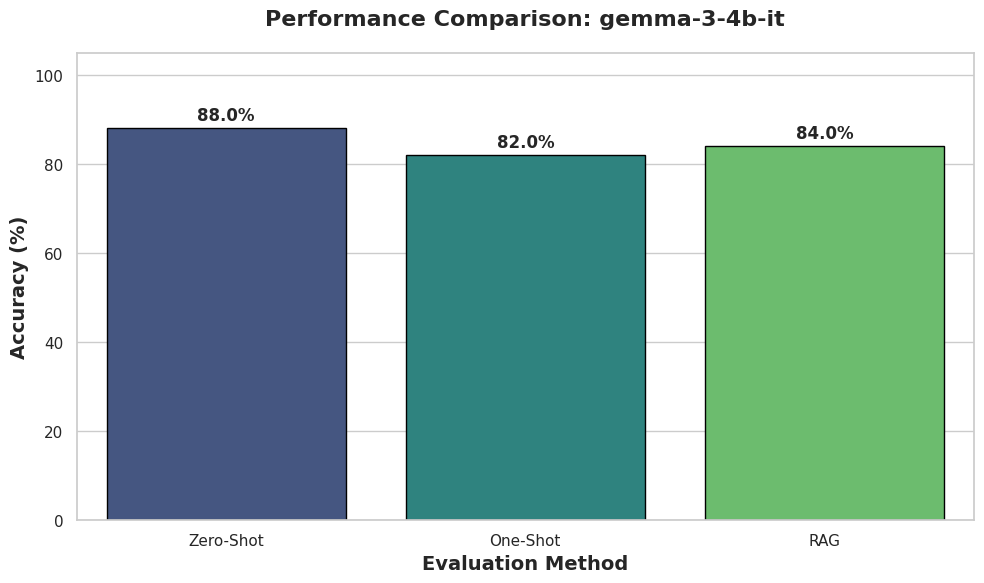

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# optional: results -> DataFrame
df_final = pd.DataFrame(gemma_results)
print("Final results:")
print(df_final)

# plot from df_final
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=df_final,
    x="Method",
    y="Accuracy",
    hue="Method",  # color by method
    palette="viridis",
    edgecolor="black",
    legend=False
)

# shared plot styling
plt.title(f"Performance Comparison: {gemma_results[0]['Model']}", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Evaluation Method", fontsize=14, fontweight='bold')
plt.ylabel("Accuracy (%)", fontsize=14, fontweight='bold')
plt.ylim(0, 105)  # headroom for bar labels

# bar value annotations
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=12, fontweight='bold')

plt.tight_layout()
# save vector figure for the thesis
plt.savefig("absa_results_plot.pdf", dpi=300)
plt.show()